# Phishing URL Detection — Feature Screening and Model Selection

Classical machine learning on **lexical and host-based URL features** to tell phishing
URLs from legitimate ones, with no page content and no network calls at inference time.

**Dataset** — [Web page phishing detection](https://www.kaggle.com/datasets/shashwatwork/web-page-phishing-detection-dataset/data)
by Shashwat Tiwari: 11 430 URLs, balanced 50/50 between phishing and legitimate, 87 extracted features.

**What this notebook does**

1. Load the dataset and check class balance.
2. Clean it — missing values, corrupted `domain_age` records, target encoding.
3. Screen features through four independent filters: multicollinearity, low variance,
   weak target correlation, low Random Forest importance.
4. Scale the survivors and split off an untouched test set.
5. Tune and compare two classifiers — **K-Nearest Neighbours** and **Logistic Regression**.

**Why it is built this way** — the model is meant to run inside a browser extension, so
every feature must be computable from the URL string alone in a few milliseconds. Features
that need an external API (`web_traffic`, `google_index`, `page_rank`) are deliberately
dropped before training, even though they are predictive: a model that depends on them
cannot be shipped.

## 1. Setup

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import (
    GridSearchCV,
    cross_val_score,
    train_test_split,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler

RANDOM_STATE = 42

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
sns.set_style("whitegrid")

The dataset lives in `/kaggle/input/...` on Kaggle and in `raw_data/` in the project
repository, so resolve it instead of hardcoding one of the two.

In [2]:
def find_dataset(filename="dataset_phishing.csv"):
    """Return the dataset path, whether running on Kaggle or from the repo."""
    candidates = [
        *Path("/kaggle/input").glob(f"**/{filename}"),
        Path("raw_data") / filename,
        Path("..") / "raw_data" / filename,
        Path(filename),
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        f"{filename} not found. On Kaggle, add the "
        "'web-page-phishing-detection-dataset' dataset to this notebook."
    )


DATA_PATH = find_dataset()
print(f"Dataset: {DATA_PATH}")

Dataset: raw_data/dataset_phishing.csv


## 2. Load and inspect

In [3]:
data = pd.read_csv(DATA_PATH)

print(f"Rows:     {data.shape[0]:,}")
print(f"Columns:  {data.shape[1]} ({data.shape[1] - 2} features + 'url' + 'status')")
data.head()

Rows:     11,430
Columns:  89 (87 features + 'url' + 'status')


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate


### Class balance

An imbalanced dataset would make plain accuracy a misleading metric — a model could score
95% by always predicting the majority class. Check before choosing how to evaluate.

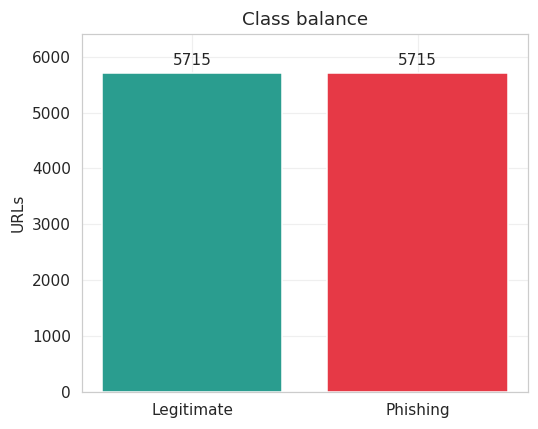

Phishing share: 50.0%


In [4]:
counts = data["status"].value_counts()

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["Legitimate", "Phishing"], [counts["legitimate"], counts["phishing"]],
              color=["#2a9d8f", "#e63946"])
ax.bar_label(bars, fmt="%d", padding=3)
ax.set_title("Class balance")
ax.set_ylabel("URLs")
ax.set_ylim(0, counts.max() * 1.12)
plt.tight_layout()
plt.show()

print(f"Phishing share: {counts['phishing'] / counts.sum():.1%}")

The classes are balanced, so accuracy is a fair headline metric. Precision and recall are
still reported per class below, because in a security setting the two error types have
different costs.

## 3. Preprocessing

Three cleaning steps:

- **Missing values** — dropped outright; they are rare enough that imputation would add
  assumptions without adding data.
- **Corrupted `domain_age`** — the extractor writes `-1` (and below) when a WHOIS lookup
  fails. Those are not real ages, and feeding them to a distance-based model would place
  the record at an arbitrary point in feature space.
- **Target encoding** — `status` becomes `1` for phishing, `0` for legitimate.

In [5]:
rows_before = len(data)

data = data.dropna()
after_na = len(data)

data = data.drop(data[data["domain_age"] <= -1].index)
after_age = len(data)

data["status"] = data["status"].map({"legitimate": 0, "phishing": 1})

print(f"Start:                     {rows_before:,}")
print(f"After dropping NaN:        {after_na:,}  (-{rows_before - after_na:,})")
print(f"After dropping bad ages:   {after_age:,}  (-{after_na - after_age:,})")
print(f"Class balance now:         {data['status'].mean():.1%} phishing")

Start:                     11,430
After dropping NaN:        11,430  (-0)
After dropping bad ages:   9,593  (-1,837)
Class balance now:         49.2% phishing


## 4. Feature screening

87 features is more than this problem needs. Redundant and uninformative features cost
inference time in the browser and, for a distance-based model like KNN, actively hurt
accuracy by diluting the distance metric.

Four independent screens run below, each against the **full** feature set. Their results
are unioned at the end, so a feature only has to fail one screen to be dropped.

In [6]:
X = data.drop(columns=["url", "status"])
y = data["status"]

# Every screen adds its rejects here; the union is applied once, at the end.
all_drops = set()

### 4.1 Correlation overview

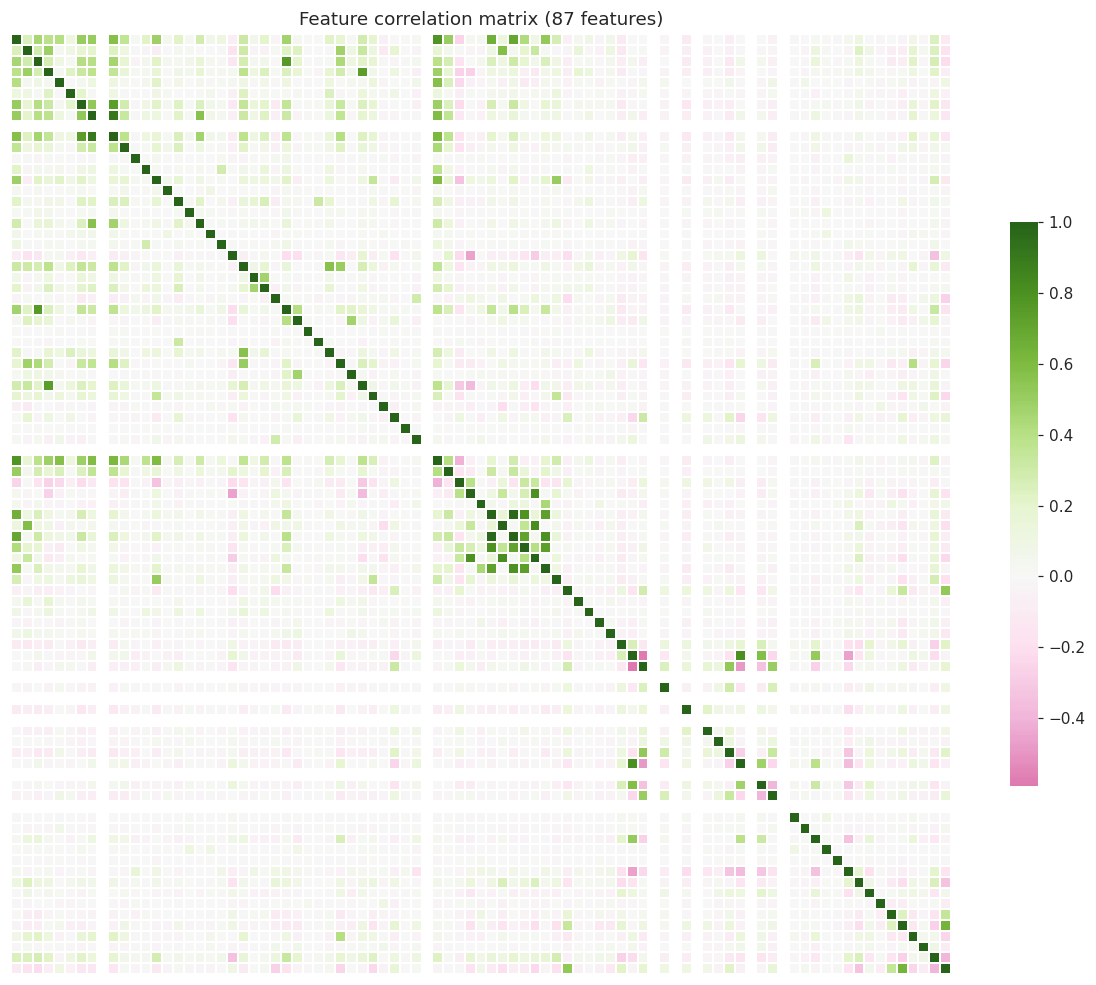

In [7]:
corr = X.corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, center=0, cmap="PiYG", square=True, linewidths=0.3,
            xticklabels=False, yticklabels=False, cbar_kws={"shrink": 0.6}, ax=ax)
ax.set_title("Feature correlation matrix (87 features)")
plt.tight_layout()
plt.show()

### 4.2 Multicollinearity

Two features that correlate strongly with **each other** carry the same information, and
the second one adds nothing. For each such pair, keep whichever correlates more strongly
with the target and drop the other.

In [8]:
CORR_PAIR_THRESHOLD = 0.75

target_corr = data.drop(columns=["url"]).corr()["status"].drop("status")

# Upper triangle only, so each pair is considered once.
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
pairs = upper.stack().reset_index()
pairs.columns = ["feature_1", "feature_2", "pair_correlation"]
pairs["feature_1_vs_target"] = pairs["feature_1"].map(target_corr)
pairs["feature_2_vs_target"] = pairs["feature_2"].map(target_corr)

redundant = pairs[pairs["pair_correlation"].abs() > CORR_PAIR_THRESHOLD].copy()
redundant["drop"] = redundant.apply(
    lambda r: r["feature_1"]
    if abs(r["feature_1_vs_target"]) < abs(r["feature_2_vs_target"])
    else r["feature_2"],
    axis=1,
)
redundant["keep"] = np.where(
    redundant["drop"] == redundant["feature_1"], redundant["feature_2"], redundant["feature_1"]
)

collinear_features = sorted(set(redundant["drop"]))
all_drops.update(collinear_features)

evidence = (
    redundant.assign(pair_correlation=redundant["pair_correlation"].round(3))
    .loc[:, ["drop", "keep", "pair_correlation"]]
    .sort_values("pair_correlation", key=abs, ascending=False)
    .reset_index(drop=True)
)

print(f"Redundant pairs above |r| > {CORR_PAIR_THRESHOLD}: {len(redundant)}")
print(f"Features dropped by this screen: {len(collinear_features)}\n")
evidence

Redundant pairs above |r| > 0.75: 9
Features dropped by this screen: 9



,drop,keep,pair_correlation
0,longest_words_raw,longest_word_path,0.970
1,nb_and,nb_eq,0.903
2,longest_word_host,avg_word_host,0.817
3,links_in_tags,ratio_intHyperlinks,0.805
4,avg_word_host,shortest_word_host,0.796
5,avg_word_path,longest_word_path,0.796
6,avg_words_raw,longest_words_raw,0.793
7,length_words_raw,length_url,0.782
8,ip,ratio_digits_url,0.759


### 4.3 Low variance

A feature that is nearly constant across every row cannot separate the classes, whatever
its relationship to the target might be in theory.

In [9]:
VARIANCE_THRESHOLD = 0.005

selector = VarianceThreshold(threshold=VARIANCE_THRESHOLD).fit(X)

# get_support() is True for features that PASS; invert it to get the failures.
low_variance_features = X.columns[~selector.get_support()].tolist()
all_drops.update(low_variance_features)

for feature in low_variance_features:
    print(f"DROP  {feature:<28} variance = {X[feature].var():.6f}")
print(f"\nFeatures dropped by this screen: {len(low_variance_features)}")

DROP  nb_or                        variance = 0.000000
DROP  nb_star                      variance = 0.000833
DROP  ratio_digits_host            variance = 0.004143
DROP  punycode                     variance = 0.000208
DROP  port                         variance = 0.002288
DROP  path_extension               variance = 0.000208
DROP  nb_external_redirection      variance = 0.000000
DROP  brand_in_subdomain           variance = 0.003843
DROP  brand_in_path                variance = 0.003221
DROP  ratio_nullHyperlinks         variance = 0.000000
DROP  ratio_intRedirection         variance = 0.000000
DROP  ratio_intErrors              variance = 0.000000
DROP  submit_email                 variance = 0.000000
DROP  sfh                          variance = 0.000000
DROP  iframe                       variance = 0.001353
DROP  onmouseover                  variance = 0.000937
DROP  right_clic                   variance = 0.001353

Features dropped by this screen: 17


### 4.4 Weak correlation with the target

A feature with essentially no linear relationship to `status` is unlikely to help the
models used here.

> **Caveat:** this screen only sees *linear* relationships. A feature with near-zero
> correlation can still be useful non-linearly — which is exactly why the Random Forest
> screen below runs as well, and why the two disagree on some features.

In [10]:
TARGET_CORR_THRESHOLD = 0.023

ranked = target_corr.abs().sort_values(ascending=False)
weak_features = ranked[ranked < TARGET_CORR_THRESHOLD].index.tolist()
all_drops.update(weak_features)

for feature in weak_features:
    print(f"DROP  {feature:<28} |corr with target| = {ranked[feature]:.4f}")
print(f"\nFeatures dropped by this screen: {len(weak_features)}")

DROP  login_form                   |corr with target| = 0.0210
DROP  shortest_words_raw           |corr with target| = 0.0156
DROP  char_repeat                  |corr with target| = 0.0154
DROP  punycode                     |corr with target| = 0.0147
DROP  nb_comma                     |corr with target| = 0.0146
DROP  iframe                       |corr with target| = 0.0136
DROP  right_clic                   |corr with target| = 0.0091
DROP  nb_space                     |corr with target| = 0.0059
DROP  random_domain                |corr with target| = 0.0030
DROP  onmouseover                  |corr with target| = 0.0029
DROP  port                         |corr with target| = 0.0008
DROP  path_extension               |corr with target| = 0.0002

Features dropped by this screen: 12


### 4.5 Random Forest importance

A Random Forest measures how much each feature reduces impurity across all trees. Unlike
correlation this captures non-linear relationships and feature interactions, so it is the
screen most likely to rescue something the linear screens would discard.

Features dropped by this screen: 51


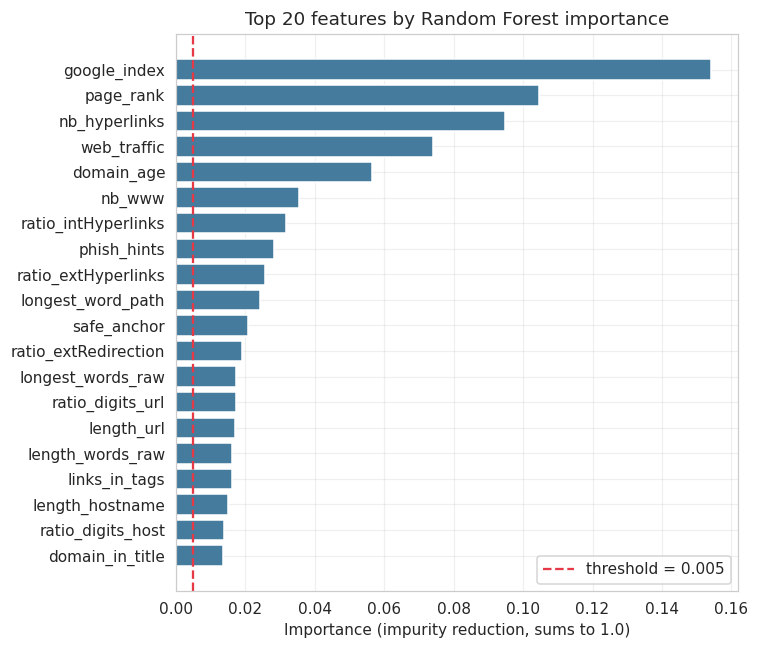

In [11]:
IMPORTANCE_THRESHOLD = 0.005

rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
low_importance_features = importances[importances < IMPORTANCE_THRESHOLD].index.tolist()
all_drops.update(low_importance_features)

print(f"Features dropped by this screen: {len(low_importance_features)}")

top = importances.head(20).sort_values()
fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(top.index, top.values, color="#457b9d")
ax.axvline(IMPORTANCE_THRESHOLD, color="#e63946", linestyle="--",
           label=f"threshold = {IMPORTANCE_THRESHOLD}")
ax.set_title("Top 20 features by Random Forest importance")
ax.set_xlabel("Importance (impurity reduction, sums to 1.0)")
ax.legend()
plt.tight_layout()
plt.show()

### 4.6 Screening summary

In [12]:
summary = pd.DataFrame(
    {
        "screen": [
            "Multicollinearity",
            "Low variance",
            "Weak target correlation",
            "Low RF importance",
        ],
        "threshold": [
            f"|r| > {CORR_PAIR_THRESHOLD}",
            f"var < {VARIANCE_THRESHOLD}",
            f"|corr| < {TARGET_CORR_THRESHOLD}",
            f"importance < {IMPORTANCE_THRESHOLD}",
        ],
        "dropped": [
            len(collinear_features),
            len(low_variance_features),
            len(weak_features),
            len(low_importance_features),
        ],
    }
)

data_filtered = data.drop(columns=list(all_drops))

print(summary.to_string(index=False))
print(f"\nUnique features dropped: {len(all_drops)}  (screens overlap)")
print(f"Features: {X.shape[1]} -> {data_filtered.shape[1] - 2}\n")
print("Kept:", ", ".join(sorted(data_filtered.columns.drop(["url", "status"]))))

                 screen          threshold  dropped
      Multicollinearity         |r| > 0.75        9
           Low variance        var < 0.005       17
Weak target correlation     |corr| < 0.023       12
      Low RF importance importance < 0.005       51

Unique features dropped: 62  (screens overlap)
Features: 87 -> 25

Kept: domain_age, domain_in_title, domain_registration_length, google_index, length_hostname, length_url, longest_word_path, nb_dots, nb_eq, nb_hyperlinks, nb_hyphens, nb_qm, nb_slash, nb_www, page_rank, phish_hints, ratio_digits_url, ratio_extErrors, ratio_extHyperlinks, ratio_extRedirection, ratio_intHyperlinks, safe_anchor, shortest_word_host, shortest_word_path, web_traffic


## 5. Scaling and train/test split

Three surviving features — `web_traffic`, `google_index` and `page_rank` — are dropped
here for a deployment reason rather than a statistical one: each needs a third-party API
call, which the browser extension cannot make on every page load without leaking the
user's browsing history. Removing them costs some accuracy and is a deliberate trade.

The remaining features are then min-max scaled to `[0, 1]`. KNN classifies by distance,
so an unscaled feature with a large range (URL length in the hundreds) would dominate one
with a small range (a 0/1 flag) for no good reason.

In [13]:
API_ONLY_FEATURES = ["web_traffic", "google_index", "page_rank"]

X_filtered = data_filtered.drop(columns=["url", "status"]).drop(
    columns=[c for c in API_ONLY_FEATURES if c in data_filtered.columns]
)
y = data_filtered["status"]

scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_filtered), columns=X_filtered.columns)

print(f"Final feature count: {X_scaled.shape[1]}")
X_scaled.head()

Final feature count: 22


,length_url,length_hostname,nb_dots,nb_hyphens,nb_qm,nb_eq,nb_slash,nb_www,ratio_digits_url,shortest_word_host,...,phish_hints,nb_hyperlinks,ratio_intHyperlinks,ratio_extHyperlinks,ratio_extRedirection,ratio_extErrors,safe_anchor,domain_in_title,domain_registration_length,domain_age
0,0.039312,0.081731,0.000000,0.000000,0.000000,0.000000,0.096774,0.0,0.304994,0.473684,...,0.0,0.006439,0.966667,0.033333,0.000000,0.000000,1.0,1.0,0.002615,0.447957
1,0.069410,0.211538,0.142857,0.023256,0.333333,0.176471,0.096774,0.0,0.208313,0.052632,...,0.0,0.000859,1.000000,0.000000,0.000000,0.000000,1.0,1.0,0.000503,0.311014
2,0.025799,0.043269,0.047619,0.046512,0.000000,0.000000,0.096774,0.5,0.000000,0.052632,...,0.0,0.021893,0.470588,0.529412,0.268519,0.018519,0.0,0.0,0.007543,0.635001
3,0.003686,0.028846,0.047619,0.000000,0.000000,0.000000,0.000000,0.5,0.000000,0.052632,...,0.0,0.021035,0.081633,0.918367,0.000000,0.000000,1.0,0.0,0.005732,0.584822
4,0.041769,0.100962,0.047619,0.000000,0.000000,0.000000,0.096774,0.5,0.358152,0.052632,...,0.0,0.006439,0.966667,0.033333,0.000000,0.000000,1.0,1.0,0.002581,0.447957


The split happens **before** any hyperparameter tuning, so the test set is never seen
during training or model selection and the final number is an honest estimate.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,  # preserve class balance in both splits
)

print(f"Train: {len(X_train):,} URLs")
print(f"Test:  {len(X_test):,} URLs")

Train: 7,674 URLs
Test:  1,919 URLs


## 6. Models

**K-Nearest Neighbours** — non-parametric and instance-based: it classifies a URL by the
majority class among its *k* closest neighbours in feature space. It makes no assumption
about the shape of the decision boundary, which suits a problem where phishing URLs may
form several unrelated clusters (typosquats, IP-literal hosts, long redirect chains).

**Logistic Regression** — parametric: it fits a single linear boundary and outputs a
calibrated probability. Fast, tiny to ship, and a good check on how linearly separable
the classes actually are.

Both are tuned with **GridSearchCV**, which tries every hyperparameter combination under
5-fold cross-validation *on the training set only*.

### 6.1 Hyperparameter search

In [15]:
knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    {"n_neighbors": [3, 4, 5, 6, 7, 8, 9, 10, 11], "metric": ["euclidean", "manhattan"]},
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)
knn_grid.fit(X_train, y_train)

print(f"KNN best params: {knn_grid.best_params_}")
print(f"KNN best CV accuracy: {knn_grid.best_score_:.4f}")

KNN best params: {'metric': 'manhattan', 'n_neighbors': 3}
KNN best CV accuracy: 0.9163


In [16]:
lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    {"C": [0.01, 0.1, 1, 10, 100], "solver": ["liblinear", "lbfgs"]},
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)
lr_grid.fit(X_train, y_train)

print(f"Logistic Regression best params: {lr_grid.best_params_}")
print(f"Logistic Regression best CV accuracy: {lr_grid.best_score_:.4f}")

Logistic Regression best params: {'C': 100, 'solver': 'lbfgs'}
Logistic Regression best CV accuracy: 0.8964


### 6.2 Training and evaluation

In [17]:
def train_and_evaluate(name, model):
    """Fit on the training set, score on the held-out test set, report both."""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # CV on the training set: if CV accuracy >> test accuracy, the model is overfitting.
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")

    print(f"=== {name} ===")
    print(f"Test accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"CV accuracy   : {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})\n")
    print(classification_report(y_test, y_pred, target_names=["Legitimate", "Phishing"]))

    return {
        "model": name,
        "estimator": model,
        "y_pred": y_pred,
        "test_accuracy": accuracy_score(y_test, y_pred),
        "cv_accuracy": cv_scores.mean(),
        "cv_std": cv_scores.std(),
    }

In [18]:
results_knn = train_and_evaluate("KNN", knn_grid.best_estimator_)

=== KNN ===
Test accuracy : 0.9265
CV accuracy   : 0.9163 (+/- 0.0067)

              precision    recall  f1-score   support

  Legitimate       0.91      0.94      0.93       975
    Phishing       0.94      0.91      0.92       944

    accuracy                           0.93      1919
   macro avg       0.93      0.93      0.93      1919
weighted avg       0.93      0.93      0.93      1919



In [19]:
results_lr = train_and_evaluate("Logistic Regression", lr_grid.best_estimator_)

=== Logistic Regression ===
Test accuracy : 0.8979
CV accuracy   : 0.8964 (+/- 0.0018)

              precision    recall  f1-score   support

  Legitimate       0.89      0.92      0.90       975
    Phishing       0.91      0.88      0.89       944

    accuracy                           0.90      1919
   macro avg       0.90      0.90      0.90      1919
weighted avg       0.90      0.90      0.90      1919



### 6.3 Comparison

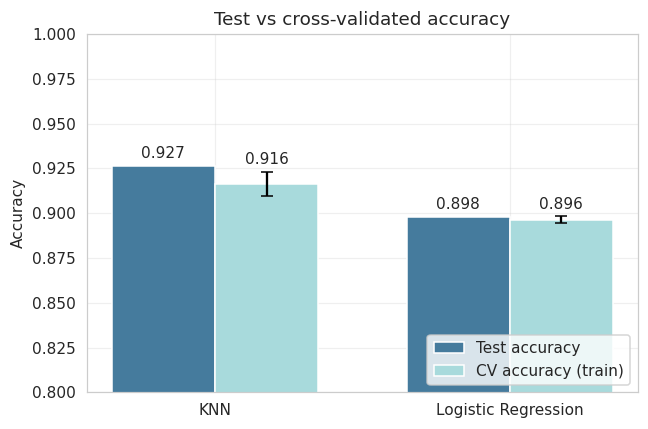

In [20]:
results = [results_knn, results_lr]
labels = [r["model"] for r in results]
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(6, 4))
b1 = ax.bar(x - width / 2, [r["test_accuracy"] for r in results], width,
            label="Test accuracy", color="#457b9d")
b2 = ax.bar(x + width / 2, [r["cv_accuracy"] for r in results], width,
            yerr=[r["cv_std"] for r in results], capsize=4,
            label="CV accuracy (train)", color="#a8dadc")
ax.bar_label(b1, fmt="%.3f", padding=3)
ax.bar_label(b2, fmt="%.3f", padding=3)
ax.set_xticks(x, labels)
ax.set_ylim(0.8, 1.0)
ax.set_ylabel("Accuracy")
ax.set_title("Test vs cross-validated accuracy")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

Test and CV accuracy agreeing closely for both models means neither is overfitting the
training set — the tuning did not leak into the final number.

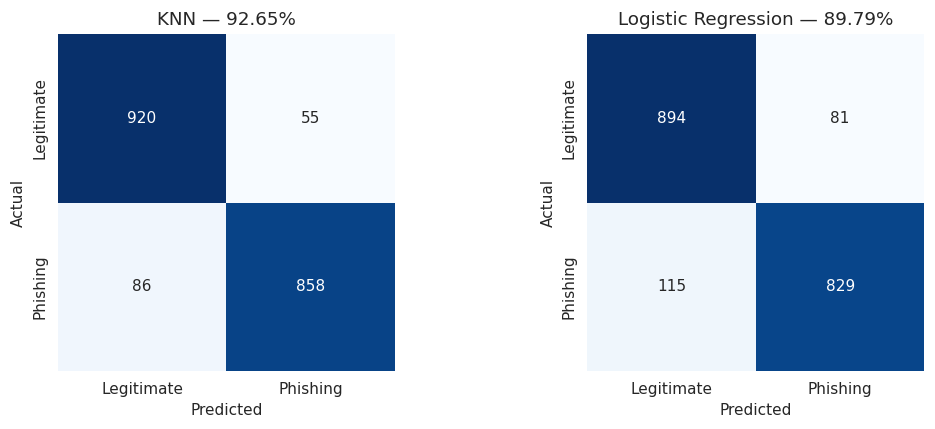

KNN                    false positives:   55   false negatives:   86
Logistic Regression    false positives:   81   false negatives:  115


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, result in zip(axes, results):
    cm = confusion_matrix(y_test, result["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, square=True,
                xticklabels=["Legitimate", "Phishing"],
                yticklabels=["Legitimate", "Phishing"], ax=ax)
    ax.set_title(f"{result['model']} — {result['test_accuracy']:.2%}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

for result in results:
    tn, fp, fn, tp = confusion_matrix(y_test, result["y_pred"]).ravel()
    print(f"{result['model']:<22} false positives: {fp:>4}   false negatives: {fn:>4}")

## 7. Conclusion

**KNN is the model to ship**, at **92.65%** test accuracy against **89.79%** for Logistic
Regression — a ~3 point gap that matters when each error is either a phishing page waved
through or a legitimate site blocked.

| | KNN | Logistic Regression |
|---|---|---|
| Test accuracy | **92.65%** | 89.79% |
| CV accuracy (train) | 91.63% (± 0.67) | 89.64% (± 0.18) |
| Best parameters | `metric=manhattan, k=3` | `C=100, solver=lbfgs` |
| False positives | 55 | 81 |
| False negatives | 86 | 115 |

Three things the numbers say:

- **Neither model overfits.** Test accuracy sits within ~1 point of cross-validated
  training accuracy for both, so the grid search did not leak the test set.
- **The classes are not linearly separable, but nearly.** Logistic Regression fits a single
  hyperplane and still reaches 89.79%, which validates the correlation-based screening —
  the surviving features do carry a mostly linear signal. KNN's extra ~3 points is the
  part of the boundary that is not linear: phishing URLs form several distinct clusters
  (IP-literal hosts, typosquats, long redirect chains) rather than one region.
- **KNN's errors are balanced.** 55 false positives against 86 false negatives, versus
  81/115 for Logistic Regression. Neither error type dominates, which is what a security
  tool wants — a model that is safe only because it flags everything is unusable.

**Cost of shipping.** Feature screening cut 87 features to 25, and dropping the three that
need a third-party API (`web_traffic`, `google_index`, `page_rank`) leaves **22**. Those
three ranked highly on Random Forest importance, so this is a real accuracy sacrifice —
paid deliberately, because an extension that phones an API on every page load would leak
the user's browsing history to do it.

**Where this is weak.** The dataset is a fixed 2020-era snapshot: the model learns what
phishing URLs looked like then, and attacker tooling moves. It also cost 1 837 rows (16%)
to the `domain_age = -1` cleanup, which is not random loss — those are domains whose WHOIS
lookup failed, plausibly correlated with being newly registered and malicious. And KNN
stores its entire training set, so inference cost grows with the data; that is affordable
at 7 674 points in a browser, and would not be at ten times the size.

### Saving the model

Persisted alongside the scaler — the extension has to apply the exact same min-max
transform at inference time, so an unsaved scaler would silently break every prediction.

In [22]:
if not Path("/kaggle").exists():  # skip on Kaggle, where there is no repo to write into
    Path("saved_models").mkdir(exist_ok=True)
    joblib.dump(knn_grid.best_estimator_, "saved_models/knn_model.pkl")
    joblib.dump(lr_grid.best_estimator_, "saved_models/lr_model.pkl")
    joblib.dump(scaler, "saved_models/scaler.pkl")
    print("Saved: knn_model.pkl, lr_model.pkl, scaler.pkl")

Saved: knn_model.pkl, lr_model.pkl, scaler.pkl
